# NBRA and non-NBRA calculations with PySCF/Libra

In this tutorial, we will first demonstrate how the existing infrastructure/functions for DFTB+ can be used to generate the files for NBRA calculations of the dynamics. Then, a non-NBRA workflow with DFTB+/Libra will be demonstrated.

## Table of contents
<a name="toc"></a>
1. [Implementation](#1)
2. [NBRA workflow](#2)

   2.1. [Local implementation](#2.1)
   
   2.2. [Libra implementation](#2.2)

3. [non-NBRA workflow](#3)
   
   

### A. Learning objectives

* To construct the Libra/PySCF interface
* To run calculations of the NACs at the CISD/CASSCF level with PySCF/Libra NBRA workflow
* To run non-NBRA calculations at the CISD/CASSCF level with PySCF/Libra interface


### B. Use cases

* compute wavefunction time-overlaps with PySCF: CISD and CASSCF levels
* non-NBRA calculations


### C. Functions

- `libra_py`
  - `packages`
    - `pyscf`
      - `implementations`
        - `casscf`
          - [`CASSCF`](#CASSCF-1)
            - [`compute_energy`](#compute_energy-1)
            - [`compute_gradient`](#compute_gradient-1)
            - [`set_geom_and_run_hf`](#set_geom_and_run_hf-1)
            - [`time_overlap_matrix`](#time_overlap_matrix-1)
        - `cisd`
          - [`CISD`](#CISD-1)
            - [`compute_energy`](#compute_energy-2)
            - [`compute_gradient`](#compute_gradient-2)
            - [`set_geom_and_run_hf`](#set_geom_and_run_hf-2)
            - [`time_overlap_matrix`](#time_overlap_matrix-2)
      - `interfaces`
        - [`MolecularGeometry`](#MolecularGeometry-1)
      - `methods`
        - [`pyscf_compute_adi`](#pyscf_compute_adi-1)


In [1]:
import os
import sys
import subprocess
import re
import copy
import numpy as np
from liblibra_core import MATRIX, CMATRIX, CMATRIXList, Py2Cpp_int, Cpp2Py, Random

# Fisrt, we add the location of the library to test to the PYTHON path
from libra_py.packages.pyscf.implementations.cisd import CISD
from libra_py.packages.pyscf.implementations.casscf import CASSCF
from libra_py.packages.pyscf.interfaces import ElectronicStructureStrategy, MolecularGeometry
import libra_py.packages.pyscf.methods as pyscf_methods

from libra_py.packages.cp2k import methods as cp2k
from libra_py import data_conv
from libra_py import units
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot

from recipes import fssh2

%matplotlib inline

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. Implementation
<a name="1"></a>[Back to TOC](#toc)

In [2]:
class tmp:
    pass

def pyscf_compute_adi(q, params, full_id):

    # ================= Decode trajectory index =================
    Id = Cpp2Py(full_id)
    itraj = Id[-1]

    # ================= Extract coordinates =================
    coords = q.col(itraj)
    coordinates = data_conv.MATRIX2nparray(coords, float).reshape(-1,3)/units.Angst # in Angstrom

    ndof = coords.num_of_rows
    nat = ndof // 3

    # ================= Safe param access =================
    params.setdefault("is_first_time", {})
    params.setdefault("act_state", {})
    #params.setdefault("pyscf_obj", {})
    params.setdefault("coords_prev", {})

    is_first_time = params["is_first_time"].get(itraj, True)
    act_state = params["act_state"].get(itraj, 0)
    
    _basis = params.get("basis", "sto-3g")
    _charge = params.get("charge", 0)
    nstates = params.get("nstates", 2)
    method = params.get("method", "casscf")
    # The default is CAS(2,2) 
    _norbcas = params.get("norbcas", 2)
    _nelecas = params.get("nelecas", 2)

    # ================= Read parameters =================
    dt = float(params.get("dt", 41.0))
    _atom_labels = params["atom_labels"]
    
    # ================= Previous coordinates =================
    
    if is_first_time:
        coords_prev = copy.deepcopy(coordinates)
    else:
        coords_prev = copy.deepcopy(params["coords_prev"].get(itraj))

    geom_prev = MolecularGeometry(atom_labels = _atom_labels, coords_angstrom=np.array(coords_prev) )
    geom = MolecularGeometry(atom_labels = _atom_labels, coords_angstrom=np.array(coordinates) )
    
        
    pyscf_obj = None
    if method=="casscf":
        pyscf_obj = CASSCF(norbcas=_norbcas, nelecas=_nelecas, nroots=nstates, basis=_basis, charge=_charge)
    elif method=="cisd":
        pyscf_obj = CISD(nroots=nstates, basis=_basis, charge=_charge)     
    
    
    pyscf_obj.set_geom_and_run_hf(geom_prev)
    _ = [pyscf_obj.compute_energy(root) for root in range(nstates)]
    _ = [pyscf_obj.compute_gradient(root) for root in range(nstates)]

    pyscf_obj.set_geom_and_run_hf(geom)
    energies = [pyscf_obj.compute_energy(root) for root in range(nstates)]
    grad = [pyscf_obj.compute_gradient(root) for root in range(nstates)]
    
    print(F"coords_prev = {coords_prev}")
    print(F"coordinates = {coordinates}")

    # ================= Compute overlaps =================
    st_ci = pyscf_obj.time_overlap_matrix(nstates)

    # ================= Build object =================
    obj = tmp()
    obj.ham_adi = CMATRIX(nstates, nstates)
    obj.nac_adi = CMATRIX(nstates, nstates)
    obj.hvib_adi = CMATRIX(nstates, nstates)
    obj.basis_transform = CMATRIX(nstates, nstates)
    obj.time_overlap_adi = CMATRIX(nstates, nstates)

    # ================= Populate Hamiltonian =================
    for i in range(nstates):
        obj.ham_adi.set(i, i, energies[i] * (1.0+0.0j) )
        obj.hvib_adi.set(i, i, energies[i] * (1.0+0.0j) )
        obj.basis_transform.set(i, i, 1.0+0.0j)

        for j in range(nstates):
            obj.time_overlap_adi.set(i, j, float(st_ci[i, j]) * (1.0+0.0j) )

    # ================== Forces ===============================
    obj.d1ham_adi = CMATRIXList()
    for idof in range(ndof):
        obj.d1ham_adi.append(CMATRIX(nstates, nstates))

    for iatom in range(nat):
        for i in range(nstates):
            obj.d1ham_adi[3 * iatom + 0].set(i, i, grad[i][iatom, 0] * (1.0 + 0.0j))
            obj.d1ham_adi[3 * iatom + 1].set(i, i, grad[i][iatom, 1] * (1.0 + 0.0j))
            obj.d1ham_adi[3 * iatom + 2].set(i, i, grad[i][iatom, 2] * (1.0 + 0.0j))

    # ================= Compute derivative couplings =================
    for i in range(nstates):
        for j in range(i + 1, nstates):
            dij = ( obj.time_overlap_adi.get(i, j) - obj.time_overlap_adi.get(j, i) ) / (2.0 * dt)
            obj.hvib_adi.set(i, j, -1j * dij)
            obj.hvib_adi.set(j, i, +1j * dij)            
            
    # ================= Store state =================
    #params["pyscf_obj"][itraj] = copy.deepcopy(pyscf_obj)
    #params["pyscf_obj"][itraj] = pyscf_obj
    params["coords_prev"][itraj] = copy.deepcopy(coordinates)
    params["is_first_time"][itraj] = False

    return obj

## 2. NBRA workflow
<a name="2"></a>[Back to TOC](#toc)

### 2.1. Local implementation
<a name="2.1"></a>[Back to TOC](#toc)

Here, we are going to use a model trajectory for LiH molecule.

Currently, two methods are included: 

- CASSCF `"mehod" : "casscf"`
- CISD `"method" : "cisd"`

For both methods, the relevant variables:

- `basis` - electronic basis set
- `charge` - the total charge of the molecule
- `nstates` - how many electronic states to consider

For `CASSCF`:

- `norbcas` - how many orbitals to include in the active space
- `nelecas` - how many electrons to include in the active space 

In [3]:
labels, q = cp2k.read_trajectory_xyz_file("LiH.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "is_first_time":{0:True},
          "act_state":{0:1},
          "basis" : "sto-3g",
          "method" : "casscf",
          "charge": 0,
          "nstates" : 4,
          "norbcas" : 4,
          "nelecas" : 2
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = cp2k.read_trajectory_xyz_file("LiH.xyz", i)
    params["timestep"] = i
    
    obj = pyscf_compute_adi(q, params, full_id)
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")


['Li', 'H']
{'atom_labels': ['Li', 'H'], 'timestep': 0, 'dt': 41.339396444811904, 'is_first_time': {0: True}, 'act_state': {0: 1}, 'basis': 'sto-3g', 'method': 'casscf', 'charge': 0, 'nstates': 4, 'norbcas': 4, 'nelecas': 2}
======== Iteration 0 ==============
CASSCF energy = -7.63327743631385
CASCI E = -7.63327743631385  E(CI) = -1.02265632596966  S^2 = 0.0000000
CASCI state-averaged energy = -7.63327743631385
CASCI energy for each state
  State 0 weight 0.25  E = -7.74480084094914 S^2 = 0.0000000
  State 1 weight 0.25  E = -7.63378158818885 S^2 = 0.0000000
  State 2 weight 0.25  E = -7.57726365805871 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.57726365805871 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0000000000     0.0000000000     0.2596432730
1 H    -0.0000000000    -0.0000000000    -0.2596432730
----------------------------------------------


Overwritten attributes  converged  of <class 'pyscf.grad.sacasscf.Gradients'>
<class 'pyscf.grad.sacasscf.Gradients'> does not have attributes  e_tot ci


--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0000000000    -0.0000000000     0.2302826976
1 H     0.0000000000     0.0000000000    -0.2302826976
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0000000000     0.0000000000     0.2405855622
1 H    -0.0000000000    -0.0000000000    -0.2405855622
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0000000000     0.0000000000     0.2405855622
1 H    -0.0000000000    -0.0000000000    -0.2405855622
----------------------------------------------
CASSCF energy = -7.63327743631385
CASCI E = -7.63327743631385  E(CI) = -1.02265632596966  S^2 = 0.0000000
CASCI state-averaged energy = -7.63327743631385
CASCI energy for each state
  State 0 weight 0.25  E =

         x                y                z
0 Li     0.0000000000    -0.0000000000     0.1194812786
1 H    -0.0000000000     0.0000000000    -0.1194812786
----------------------------------------------
coords_prev = [[0.  0.  0. ]
 [0.  0.  1.1]]
coordinates = [[0.  0.  0. ]
 [0.  0.  1.2]]
======== Iteration 3 ==============
CASSCF energy = -7.69747947287606
CASCI E = -7.69747947287606  E(CI) = -1.00208175611653  S^2 = 0.0000000
CASCI state-averaged energy = -7.69747947287606
CASCI energy for each state
  State 0 weight 0.25  E = -7.81123368437354 S^2 = 0.0000000
  State 1 weight 0.25  E = -7.69529821247565 S^2 = 0.0000000
  State 2 weight 0.25  E = -7.64169299732753 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.64169299732753 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0000000000     0.0000000000     0.1078370611
1 H    -0.0000000000    -0.0000000000    -0.1078370611
----------------------------

### 2.2. Libra implementation
<a name="2.2"></a>[Back to TOC](#toc)

In [4]:
labels, q = cp2k.read_trajectory_xyz_file("LiH.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "is_first_time":{0:True},
          "act_state":{0:1},
          "basis" : "sto-3g",
          "method" : "casscf",
          "charge": 0,
          "nstates" : 4,
          "norbcas" : 4,
          "nelecas" : 2
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results2"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = cp2k.read_trajectory_xyz_file("LiH.xyz", i)
    params["timestep"] = i
    
    obj = pyscf_methods.pyscf_compute_adi(q, params, full_id)
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")


['Li', 'H']
{'atom_labels': ['Li', 'H'], 'timestep': 0, 'dt': 41.339396444811904, 'is_first_time': {0: True}, 'act_state': {0: 1}, 'basis': 'sto-3g', 'method': 'casscf', 'charge': 0, 'nstates': 4, 'norbcas': 4, 'nelecas': 2}
======== Iteration 0 ==============
CASSCF energy = -7.63327743631385
CASCI E = -7.63327743631385  E(CI) = -1.02265632596966  S^2 = 0.0000000
CASCI state-averaged energy = -7.63327743631385
CASCI energy for each state
  State 0 weight 0.25  E = -7.74480084094914 S^2 = 0.0000000
  State 1 weight 0.25  E = -7.63378158818884 S^2 = 0.0000000
  State 2 weight 0.25  E = -7.57726365805871 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.57726365805871 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0000000000     0.0000000000     0.2596432730
1 H    -0.0000000000    -0.0000000000    -0.2596432730
----------------------------------------------
--------------- StateAverageCASSCF gradients ----

  State 2 weight 0.25  E = -7.65219922548089 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.65219922548089 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0000000000     0.0000000000     0.1155899304
1 H     0.0000000000    -0.0000000000    -0.1155899304
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0000000000     0.0000000000     0.1148835599
1 H     0.0000000000    -0.0000000000    -0.1148835599
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0000000000    -0.0000000000     0.1194812786
1 H     0.0000000000     0.0000000000    -0.1194812786
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x               

In [5]:
print(1)

1


In [8]:
for i in range(5):
    s = np.loadtxt(F"results/st_adi_{i}.txt")
    s2 = np.loadtxt(F"results2/st_adi_{i}.txt")
    print(np.abs(s - s2))
    print(i, np.max(np.abs(s - s2)))

[[1.08000000e-05 5.28015180e-04 1.14312138e-15 2.03681400e-16]
 [5.28015180e-04 1.35200000e-05 7.74280740e-14 1.41829608e-13]
 [7.76853167e-16 9.99720820e-14 4.33718660e-01 4.73716050e-01]
 [1.45680974e-15 1.54822110e-14 4.84448160e-01 5.73177990e-01]]
0 0.57317799
[[2.53300000e-05 2.85572000e-05 4.66339290e-03 2.05524868e-03]
 [2.83424000e-05 3.19500000e-05 1.14757247e-02 5.05757684e-03]
 [4.48342030e-03 1.24277352e-02 7.74547900e-02 4.15996922e-01]
 [3.33459390e-03 9.24326670e-03 3.95122580e-01 9.95315300e-02]]
1 0.4159969225
[[9.74070000e-04 9.30789510e-03 3.43310000e-04 2.30222106e-03]
 [1.31916524e-02 1.24523000e-03 8.90122690e-03 1.32736170e-03]
 [8.55489830e-04 1.93386231e-03 2.50716990e-01 1.16062269e+00]
 [3.67195010e-03 4.50550700e-04 1.60734971e+00 5.73601580e-01]]
2 1.60734971
[[5.02410000e-04 5.66400500e-04 3.09068210e-03 8.08978860e-04]
 [5.69691200e-04 6.42260000e-04 1.13434246e-02 2.96911510e-03]
 [3.14779700e-03 1.00950196e-02 3.16024450e-01 7.87081393e-01]
 [1.6552879

## 3. Non-NBRA calculations
<a name="3"></a>[Back to TOC](#toc)

The calculations are organized into several blocks:

1. Specification of the molecule and key variables 
2. Nuclear and electronic initial conditions
3. Defining dynamical parameters
4. Setting up the model (PySCF) parameters
5. Running calculations
6. Plotting the results

### 3.1. Molecule
<a name="3.1"></a>[Back to TOC](#toc)

For a molecule of `N` atoms, we need:

- `labels`: chemical symbols of all atoms in the molecule (length of N)
- `coords`: coordinates of all atoms (as a 1D list with 3N elements, units: Angstrom)
- `nstates`: the total number of electronic states to consider (including the groundstate)
- `ntraj`: how many trajectories we are going to run
- `mass_dict`: make sure to define the masses (in amu, hydrogen atom 1 amu) of all chemical species in your system

In [35]:
labels = ['Li', 'H']

coords = [ 0.000,  0.000,  0.0000,
           0.000,  0.000,  1.0000    ]

ndof = len(coords)

q = [x*units.Angst for x in coords ]
p = [0.0 for _ in range(ndof)]

mass = []
mass_dict = {"Li":7.0, "H":1.0 }
for elt in labels:
    m = mass_dict[elt] * units.amu
    mass.append(m)
    mass.append(m)
    mass.append(m)

print(F"ndof = {ndof}")
nat = len(labels)
print(F"nat = {nat}")

nstates = 4
ntraj = 2

ndof = 6
nat = 2


### 3.2. Initial conditions - nuclear and electronic
<a name="3.2"></a>[Back to TOC](#toc)

**Nuclear parameters**
- `ndof`: the number of degrees of freedom (3N) - defined above
- `q`: average positions of coordinates (Bohr) - defined above
- `p`: average momenta - defined above
- `mass`: masses of all DOFs - defined above
- `init_type = 4`: defined q and p spread manually
- `q_width` and `p_width`: set up some reasonable values

--- 

**Electronic parameters**

- `istate = 2`: initial electronic state
- `rep = 1`: initial states are chosen as adiabatic
- `init_type = 1` : initialize random phases of non-zero electronic amplitudes

In [37]:
############################################################
### 1. Choose the initial conditions: Nuclear and Electronic
############################################################

# Nuclear initial conditions 
nucl_params = { "ndof":ndof,
                "q":q, "p":p,
                "mass":mass,
                "force_constant":[ 0 for _ in range(ndof) ],
                "q_width":[ 0.25 for _ in range(ndof)  ],
                "p_width":[ 0.1 for _ in range(ndof)  ],
                "init_type": 4
              }

# Electronic initial conditions - start on the second adiabatic state (starting from 0 = ground)
##########
istate = 2
##########
istates = [0.0 for i in range(nstates)]
istates[istate] = 1.0     
elec_params = {"verbosity":2, "init_dm_type":0,"ndia":nstates, "nadi":nstates, 
               "rep":1, "init_type":1, "istates":istates, "istate":istate     }

### 3.3. Dynamical parameters
<a name="3.3"></a>[Back to TOC](#toc)

- `nsteps = 5` : for how many steps to integrate the dynamics
- `ntraj` : how many trajectories - defined above
- `nstates` : how many electronic states - defined above

**IMPORTANT: many essential parameters are loaded from the `recipes/fssh2.py`, which is taylored for this kind of workflow**

> this is not a generic recipe for model-based calculations. In this case, the recipe is desgned to read adiabatic properties and avoid obtaining adiabatic properties from the diabatic (which are not given)

In [58]:
###########################################################
### 2. Dynamics parameters
###########################################################

dyn_general = { "nsteps":5, "ntraj":ntraj, "nstates":nstates,
                "dt":41.0, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.5, "which_adi_states":range(nstates), "which_dia_states":range(nstates),
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "states", "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia"],
                "prefix":"adiabatic_md", "prefix2":"adiabatic_md"
              }
fssh2.load(dyn_general) # FSSH2

### 3.4. Model parameters
<a name="3.4"></a>[Back to TOC](#toc)

The parameters of CISD or CASSCF are described above in section 2.

In [59]:
###########################################################
### 3. Model parameters
###########################################################
wd = "non_nbra_wd"

# Create working directory, if doesn't exist
if not os.path.exists(wd):
    os.mkdir(wd)

model_params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "basis" : "sto-3g",
          "method" : "casscf",
          "charge": 0,
          "nstates" : 4,
          "norbcas" : 4,
          "nelecas" : 2,
          
          "act_state": { i:istate for i in range(nstates) },
          "is_first_time" : { i:True for i in range(nstates) },
          
          "model": 0,
          "model0": 0
         }


### 3.5. Run calculations
<a name="3.5"></a>[Back to TOC](#toc)

This part is the same as for model calculations, but notice that instead of passing some model Hamiltonian function, we use `dftb.dftb_compute_adi` function
<a name="dftb_compute_adi-2"></a>

In [60]:
dyn_params = dict(dyn_general)
pref = "FSSH2_"
dyn_params.update({ "prefix":pref, "prefix2":pref })
print(F"Computing {pref}")    

rnd = Random()
res = tsh_dynamics.generic_recipe(dyn_params, pyscf_compute_adi, model_params, elec_params, nucl_params, rnd)

Computing FSSH2_
Active states (adiabatic)
[2, 2]
Initial adiabatic populations
[0.0, 0.0, 1.0, 0.0]
_width is not defined! in the input parametersUse the default value 
In cctor: lvl = 1 der_lvl = 2
======= Initialization type is 1 ========
setting representation 1 coefficient to complex C_2 such that |C_2}|^2 = 1.0
======= Initialization type is 1 ========
setting representation 1 coefficient to complex C_2 such that |C_2}|^2 = 1.0
========== ampl_dia ===============
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  

========== ampl_adi ===============
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0042989756,0.99999076)  (0.40283762,-0.91527146)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  

========== states ===============
======= Initialization type is 0 ========
setting DM in representation 

CASCI E = -7.65040948105544  E(CI) = -1.02030964964120  S^2 = 0.0000000
CASCI state-averaged energy = -7.65040948105544
CASCI energy for each state
  State 0 weight 0.25  E = -7.76304370034193 S^2 = 0.0000000
  State 1 weight 0.25  E = -7.65005038801095 S^2 = 0.0000000
  State 2 weight 0.25  E = -7.59427191793443 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.59427191793443 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0202657219    -0.0261703816     0.2183723455
1 H     0.0202657219     0.0261703816    -0.2183723455
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0182131983    -0.0235198307     0.1962554726
1 H     0.0182131983     0.0235198307    -0.1962554726
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x         

         x                y                z
0 Li    -0.0163673108     0.0179937560     0.1138691128
1 H     0.0163673108    -0.0179937560    -0.1138691128
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0172173513     0.0189156150     0.1199085969
1 H     0.0172173513    -0.0189156150    -0.1199085969
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0172173544     0.0189156191     0.1199086122
1 H     0.0172173544    -0.0189156191    -0.1199086122
----------------------------------------------
CASSCF energy = -7.70249823468916
CASCI E = -7.70249823468916  E(CI) = -1.00249462848920  S^2 = 0.0000000
CASCI state-averaged energy = -7.70249823468916
CASCI energy for each state
  State 0 weight 0.25  E = -7.80934551711043 S^2 = 0.0000000
  State 1 weight 0.25  E =

CASCI state-averaged energy = -7.79177577907083
CASCI energy for each state
  State 0 weight 0.25  E = -7.8751568750613 S^2 = 0.0000000
  State 1 weight 0.25  E = -7.79410203527855 S^2 = 0.0000000
  State 2 weight 0.25  E = -7.74892347420459 S^2 = 0.0000000
  State 3 weight 0.25  E = -7.74892073173888 S^2 = 0.0000000
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0026769882    -0.0029202389    -0.0188502151
1 H    -0.0026769882     0.0029202389     0.0188502151
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li     0.0005708549    -0.0005933555    -0.0043114563
1 H    -0.0005708549     0.0005933555     0.0043114563
----------------------------------------------
--------------- StateAverageCASSCF gradients ---------------
         x                y                z
0 Li    -0.0007821489     0.0008779750     0.00

### 3.6. Let's visualize some properties 
<a name="3.6"></a>[Back to TOC](#toc)

Again, we can re-use the plotting functions used for model Hamiltonians, although some more post-processing will be needed to generate the MD trajectories of the systems evolving in their excited-state

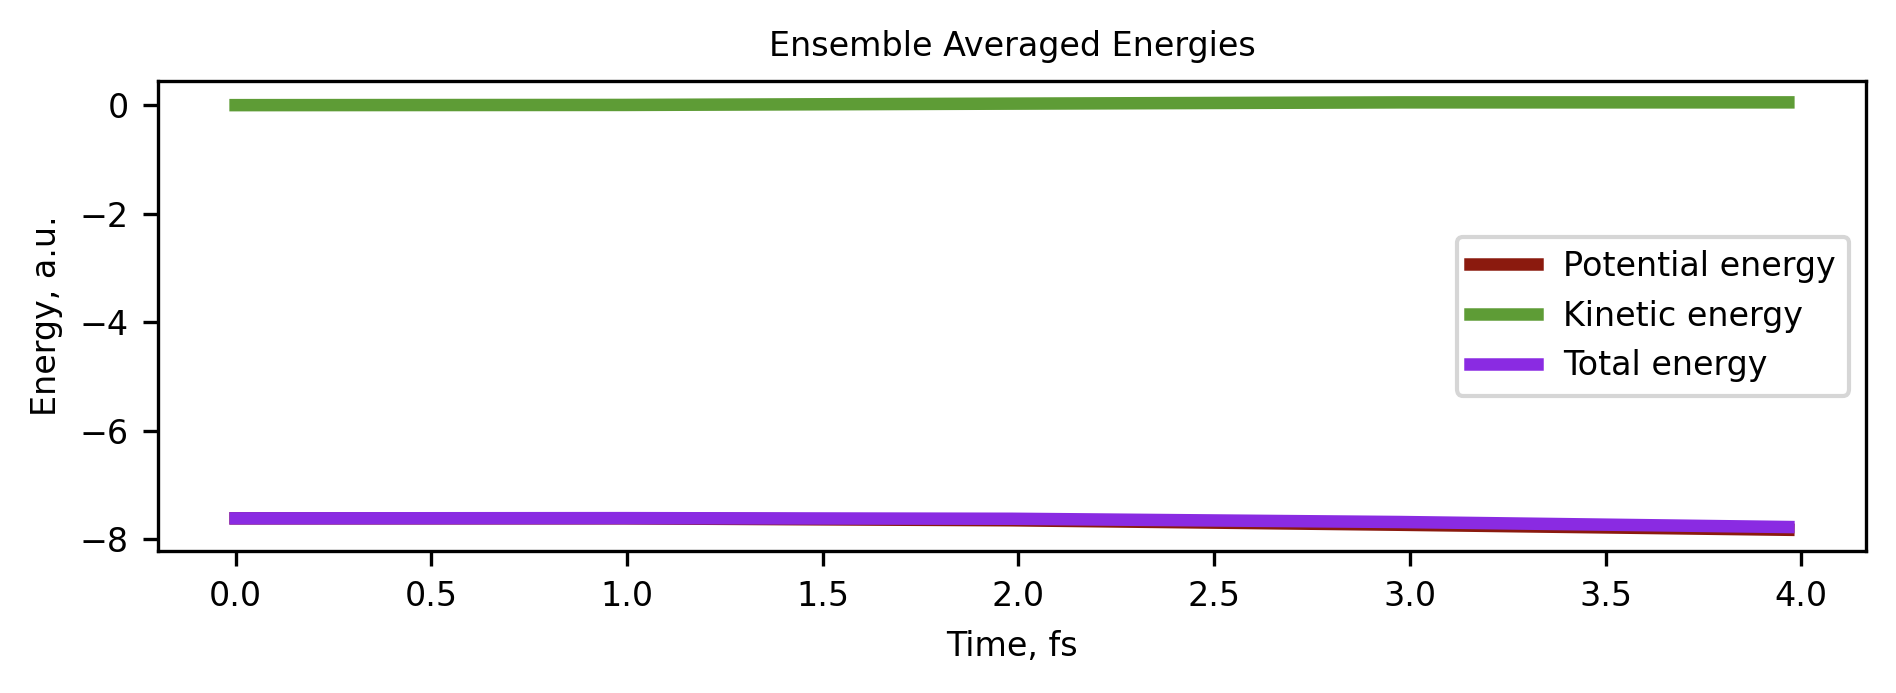

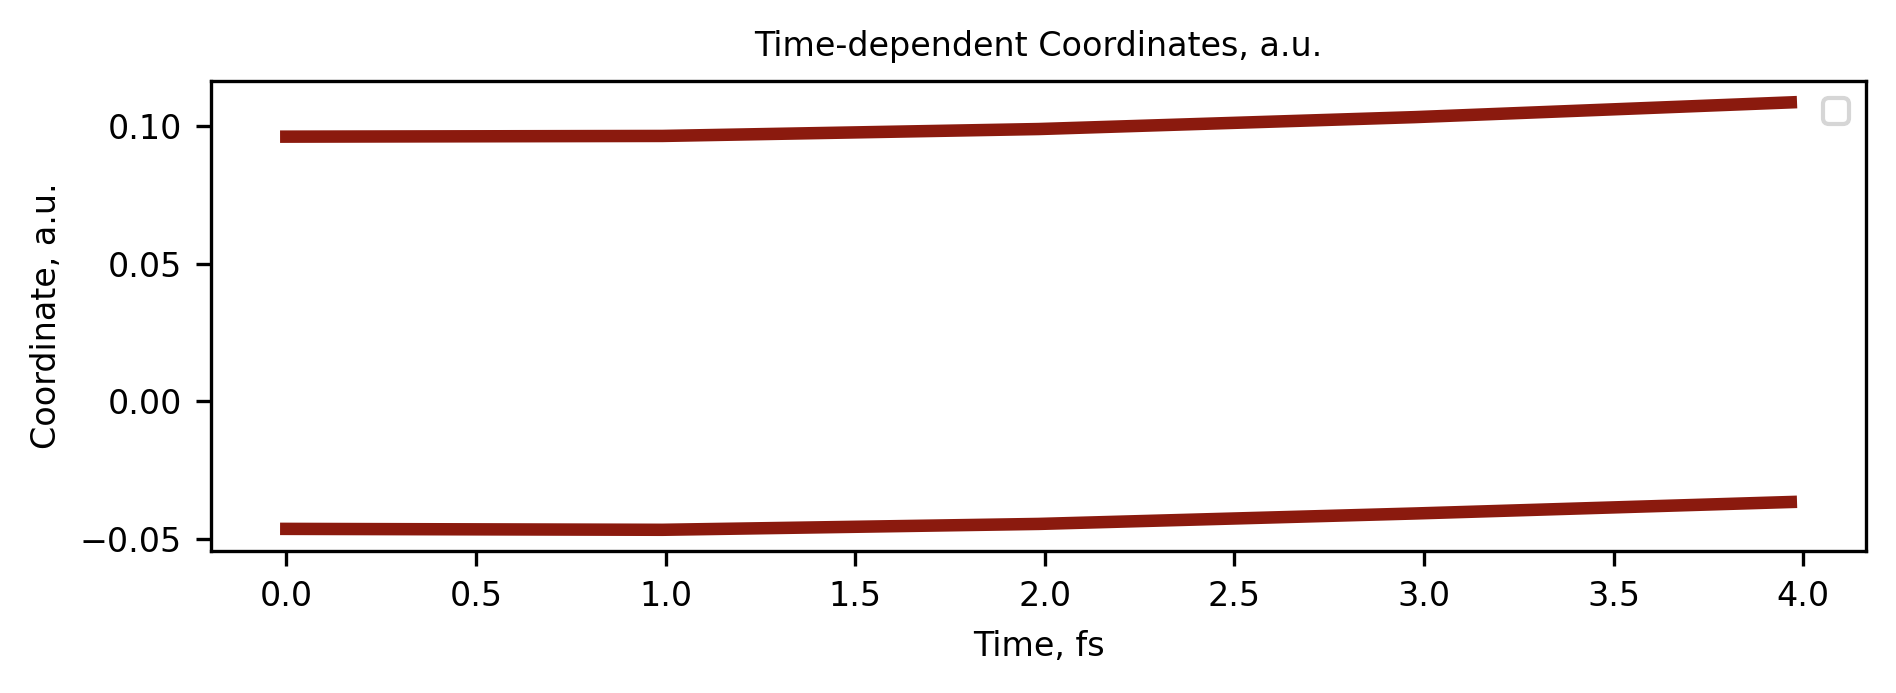

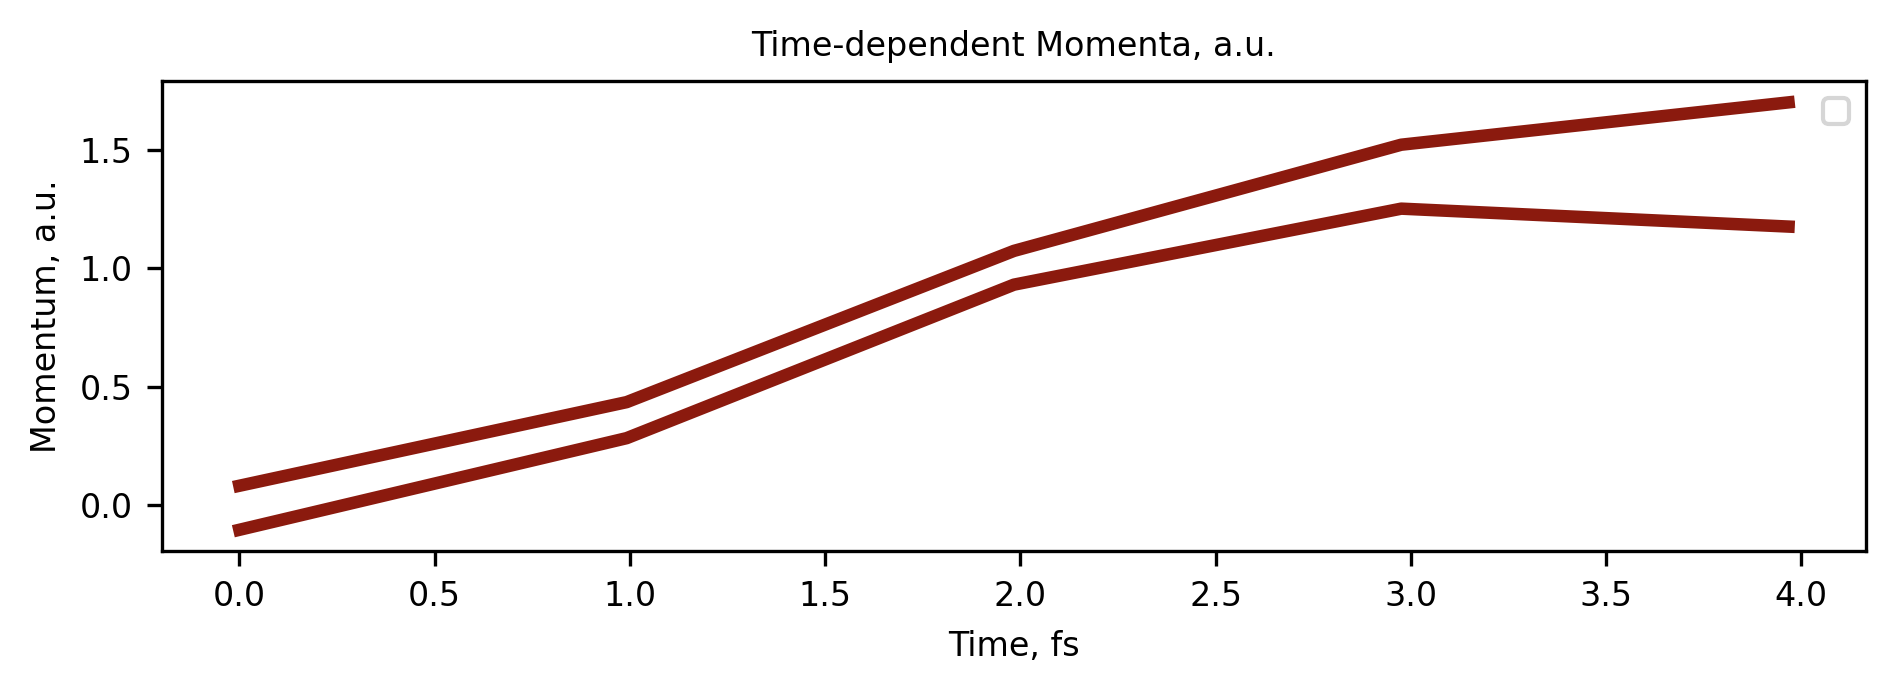

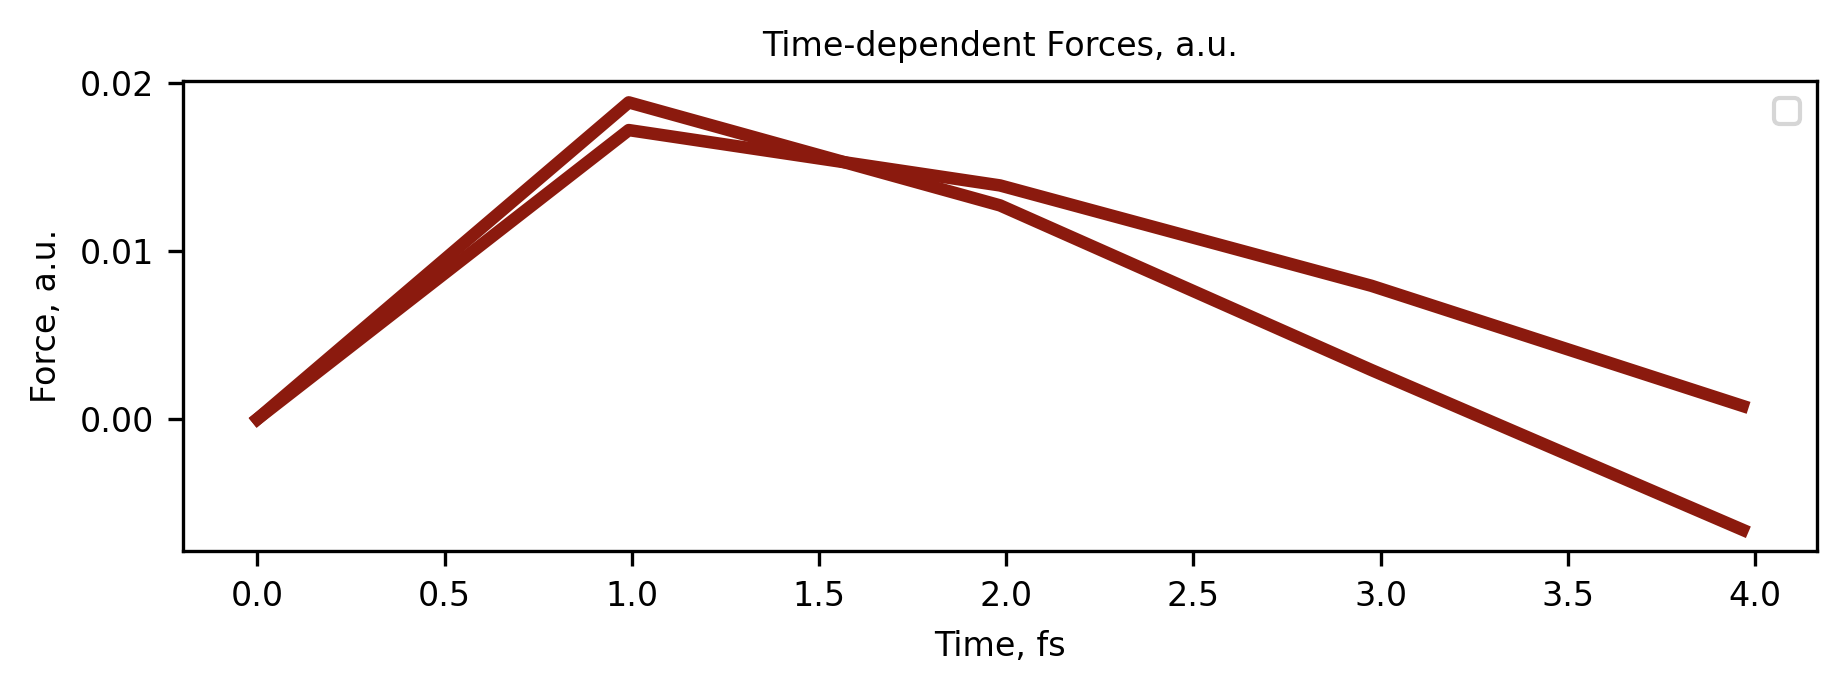

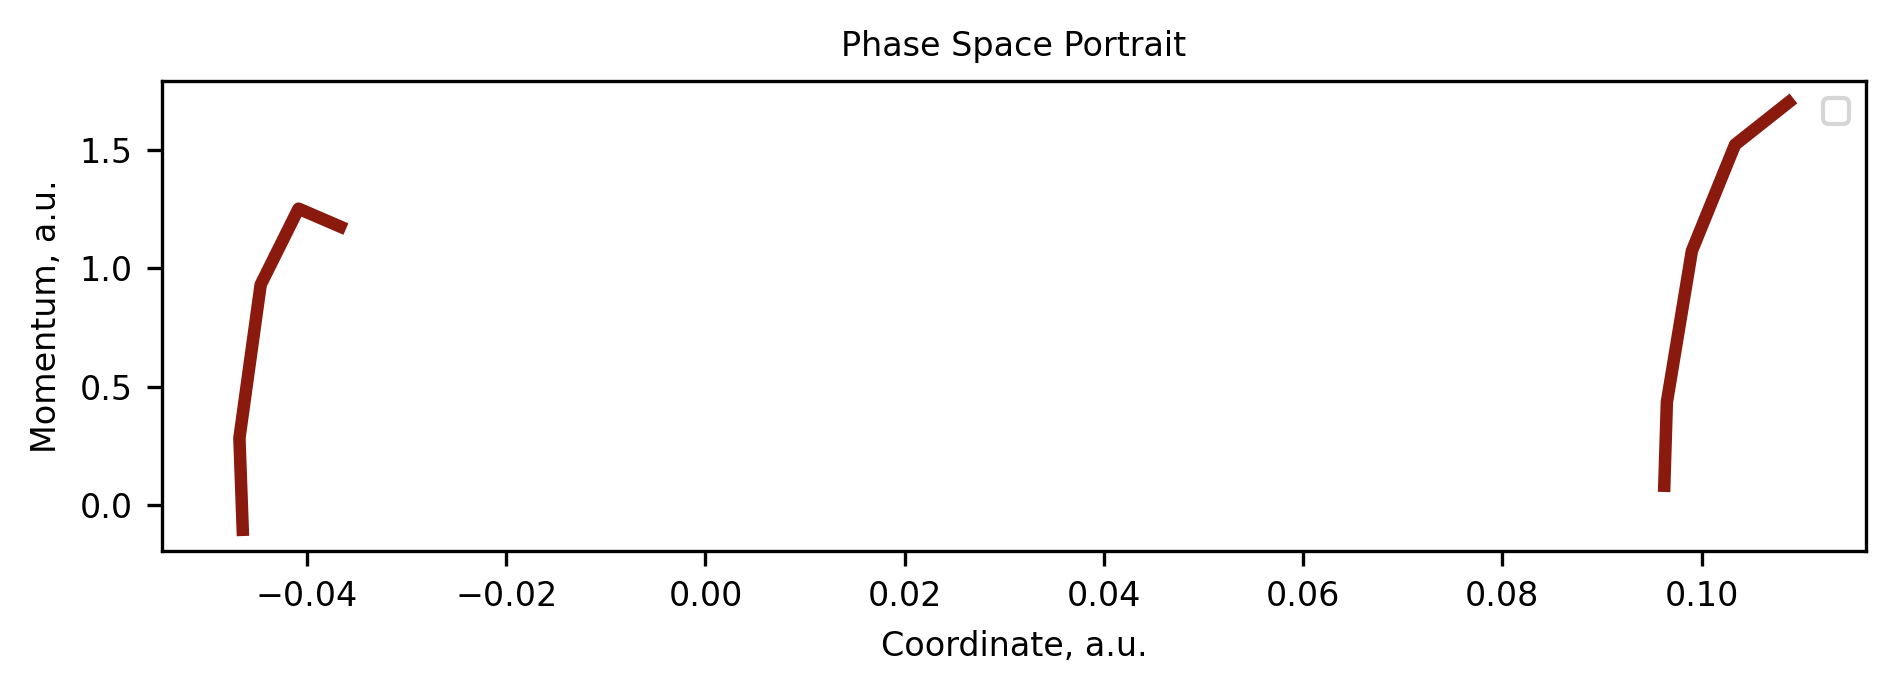

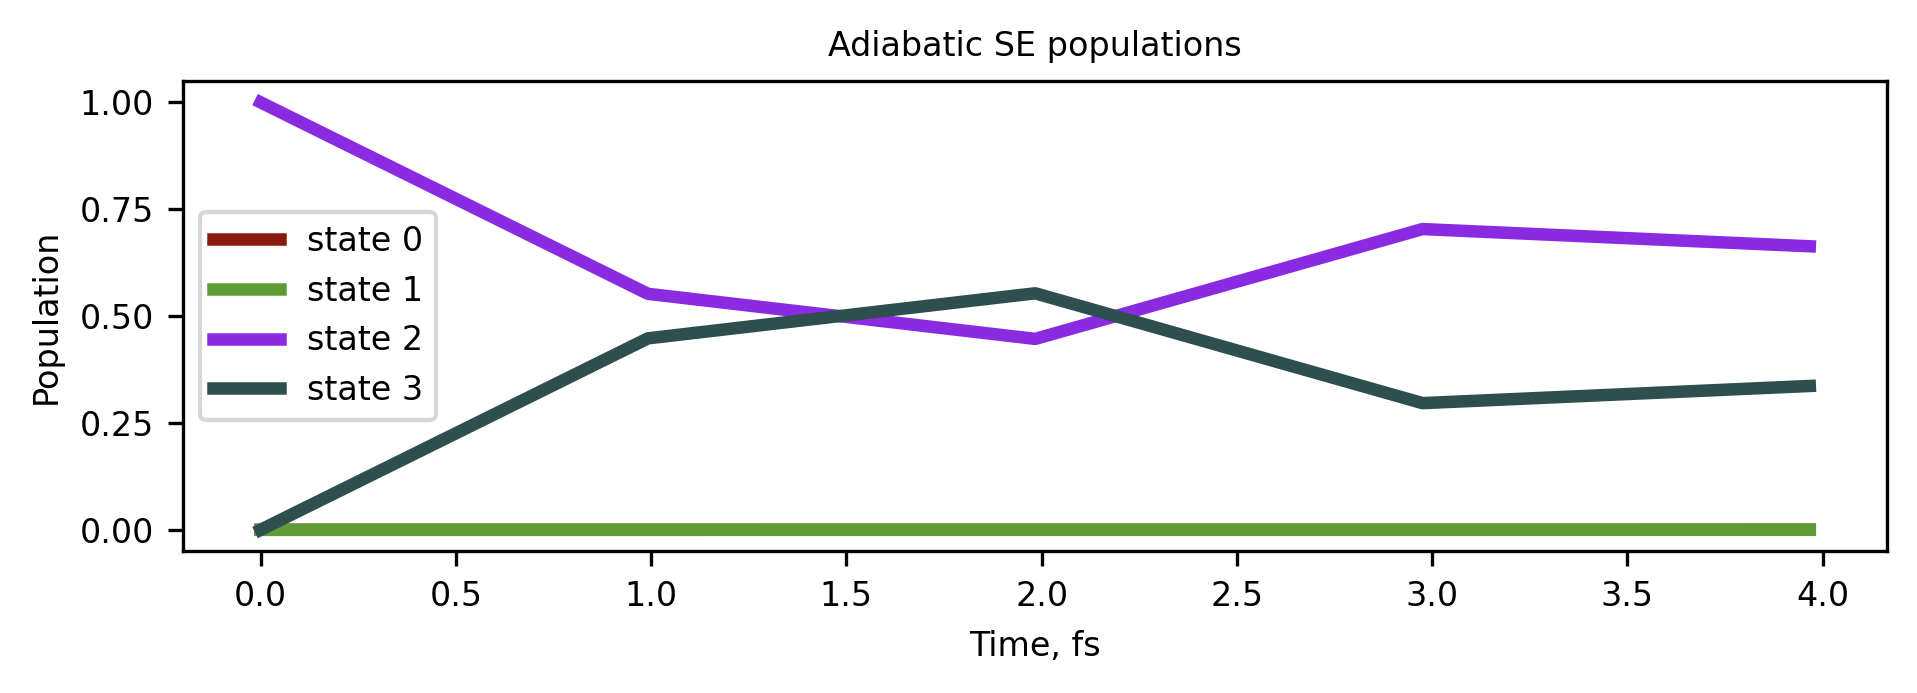

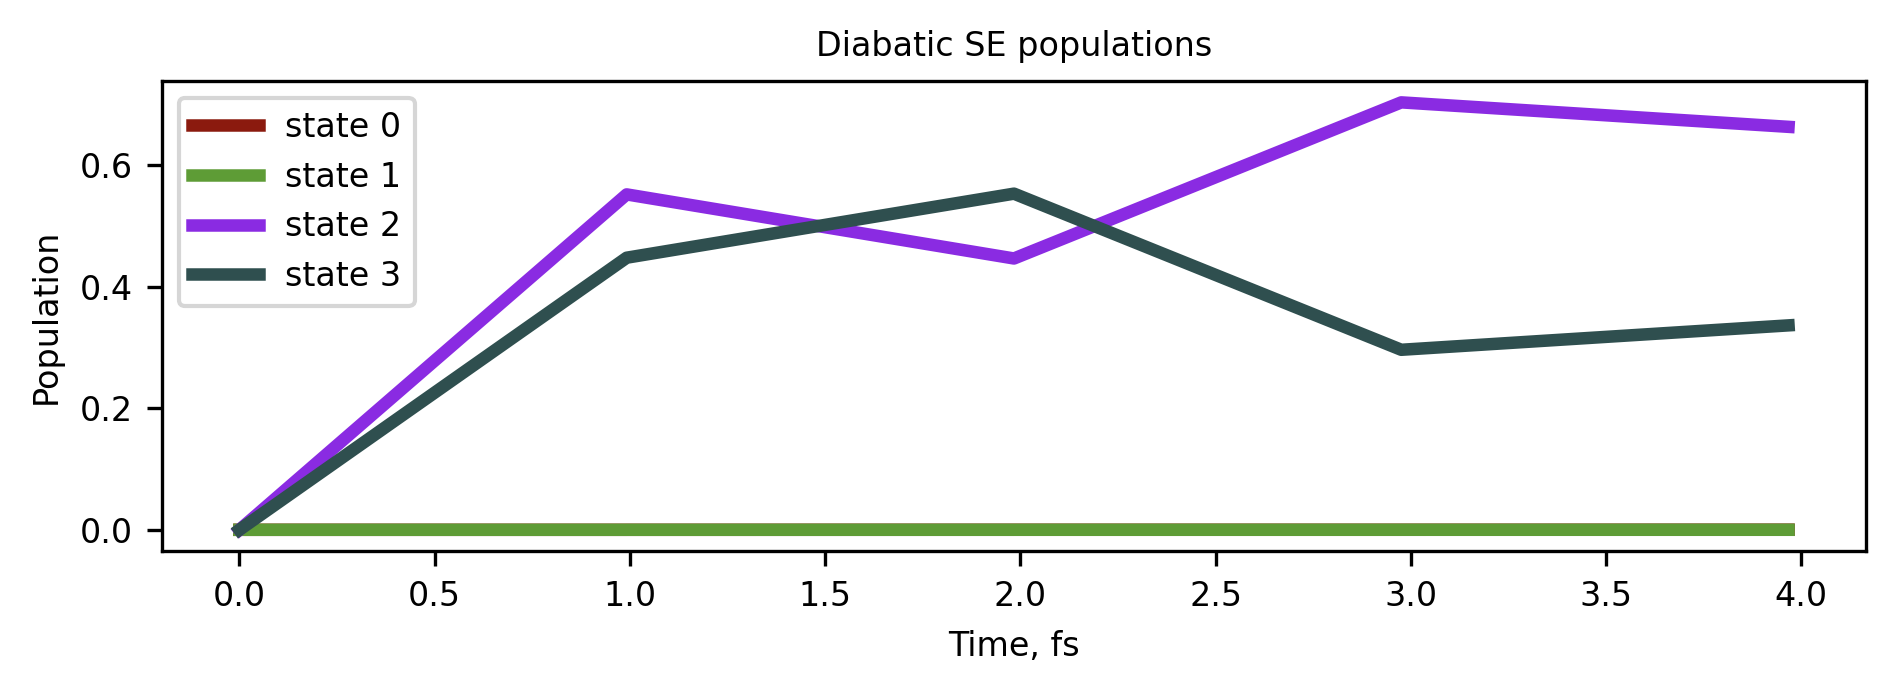

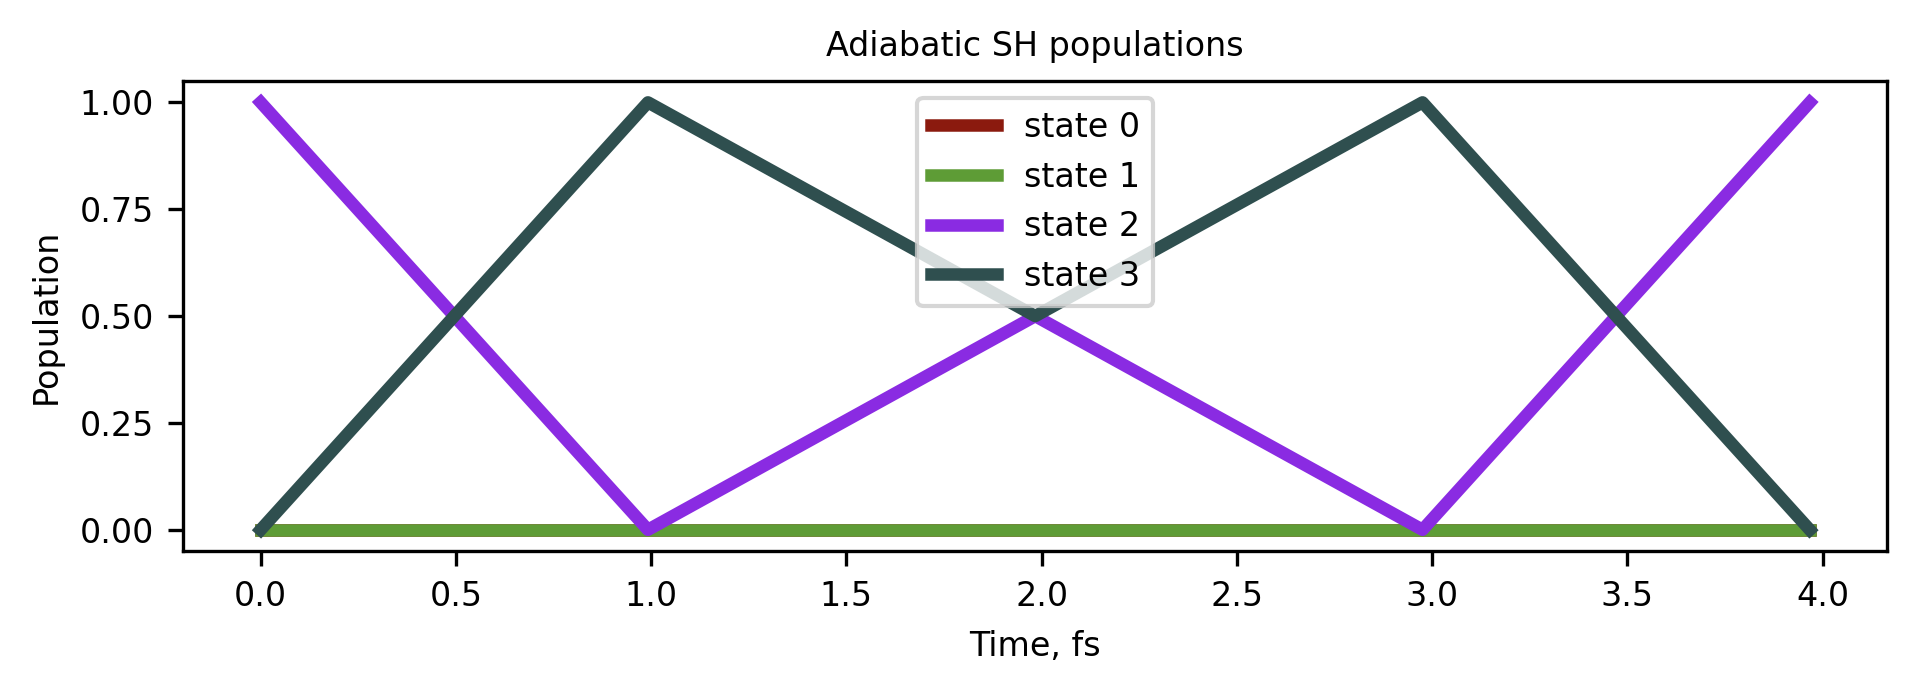

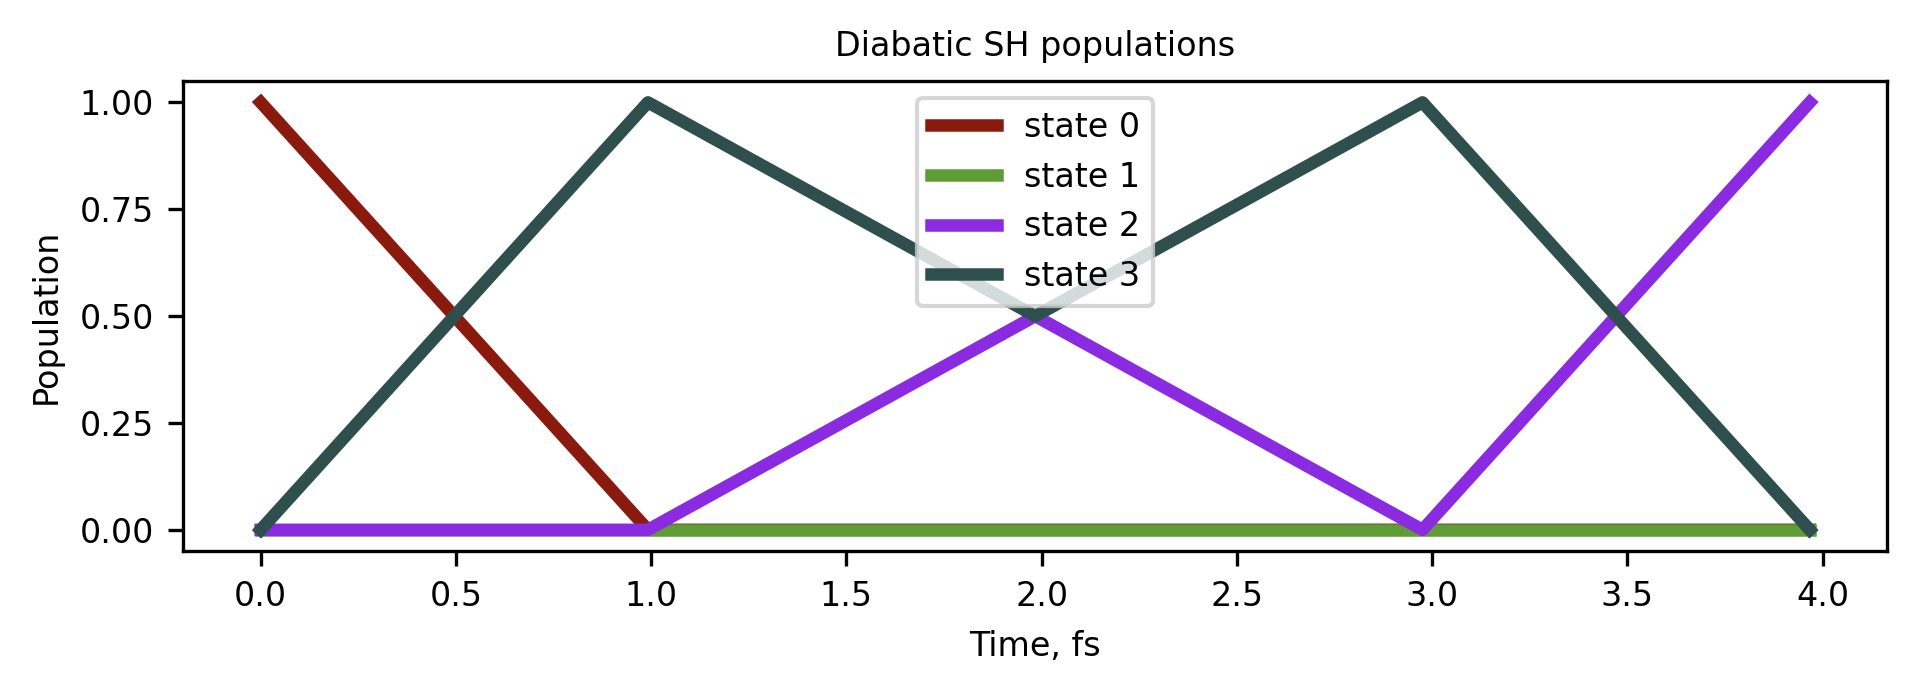

In [61]:
############################################################
### 5. Plot the results - preliminary plotting
############################################################
pref = "FSSH2_"
NSTATES = nstates

NTRAJ = dyn_general["ntraj"]
plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":3,
                "which_trajectories":list(range(NTRAJ)), "which_dofs":[0], "which_adi_states":list(range(NSTATES)), 
                "which_dia_states":list(range(NSTATES)), 
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8, "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":["coordinates", "momenta",  "forces", "energies", "phase_space", "se_pop_adi",
                                "se_pop_dia", "sh_pop_adi", "sh_pop_dia" ], 
                "which_energies":["potential", "kinetic", "total"],
                "save_figures":0, "do_show":1, "no_label":1
              }
tsh_dynamics_plot.plot_dynamics(plot_params)

### 3.7. Bond distance dynamics
<a name="3.7"></a>[Back to TOC](#toc)

For this diatomic, we can also compute the bond length as a function of time

In [62]:
import h5py

In [63]:
q = None
with h5py.File("FSSH2_/mem_data.hdf", 'r') as f:
    q = np.array(f["q/data"])
    #print(q)
print(q)

[[[-0.0464518   0.03863636 -0.27758369 -0.22682272 -0.19428778
    1.66599474]
  [ 0.0962553  -0.17708793  0.19416507 -0.21497669  0.16265815
    2.38341164]]

 [[-0.04678519  0.03928753 -0.2777767  -0.2257876  -0.19469309
    1.66544015]
  [ 0.09651495 -0.1775805   0.19444746 -0.21683377  0.16606178
    2.38283479]]

 [[-0.04465053  0.04317548 -0.30481687 -0.24202882 -0.2177558
    1.85281561]
  [ 0.0990265  -0.18054707  0.17904661 -0.23445413  0.18678345
    2.4920405 ]]

 [[-0.0408511   0.04927854 -0.35012834 -0.26992349 -0.25632431
    2.16809023]
  [ 0.10335843 -0.18552655  0.15109686 -0.2648171   0.22159548
    2.68908857]]

 [[-0.03667011  0.0558827  -0.39959385 -0.30048896 -0.2984005
    2.51244309]
  [ 0.10872859 -0.19166074  0.11605598 -0.30244779  0.26449048
    2.93577453]]]


In [64]:
q.shape

(5, 2, 6)

In [65]:
def bond_dist(r):
    R = np.sqrt((r[:,:,0]-r[:,:,3])**2 + (r[:,:,1]-r[:,:,4])**2 + (r[:,:,2]-r[:,:,5])**2)
    return R

In [66]:
dist = bond_dist(q)

In [67]:
print(dist)

[[1.96577833 2.23720659]
 [1.96542121 2.23725649]
 [2.18229724 2.36560389]
 [2.5470163  2.59667162]
 [2.94534822 2.88581923]]
